In [2]:
import json
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import re

## Считывание файла данных

In [4]:
sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)

In [6]:
path = Path("./data.json")

with path.open("r", encoding="utf-8") as f:
    data = json.load(f)

type(data), len(data), data[0]

(list,
 1774,
 {'idx': '10026',
  'text': '[PERSON]\n\nУважаемый [PERSON]!\n\n[ORGANIZATION] высоко ценит сложившиеся отношения между нашими предприятиями и заинтересовано в предоставлении геофизических услуг на объектах [ORGANIZATION].\n\nСогласно письму [ORGANIZATION] от [DATE_TIME] No [DOCUMENT_NUMBER] о формировании бизнес-плана и СИП на 2025–2027 гг. просим Вас учесть индексацию расценок на услуги внутреннего сервиса на 2025 год в размере [FINANCIAL_DATA] при формировании бизнес-плана и заключении новых договоров на 2025 год и последующие годы, а также предлагаем Вам заключить дополнительные соглашения с индексацией расценок на 2025 год к следующим действующим договорам:\n\n* [DOCUMENT_NUMBER] от [DATE_TIME];\n* [DOCUMENT_NUMBER] от [DATE_TIME];\n* [DOCUMENT_NUMBER] от [DATE_TIME];\n* [DOCUMENT_NUMBER] от [DATE_TIME];\n* [DOCUMENT_NUMBER] от [DATE_TIME];\n* [DOCUMENT_NUMBER] от [DATE_TIME];\n* [DOCUMENT_NUMBER] от [DATE_TIME];\n* [DOCUMENT_NUMBER] от [DATE_TIME];\n* [DOCUMENT_NUMB

## Первичный анализ данных

In [8]:
df = pd.DataFrame(data)
df.head()

,idx,text,label
0,10026,[PERSON]\n\nУважаемый [PERSON]!\n\n[ORGANIZATION] высоко ценит сложившиеся отношения между нашими предприятиями и за...,Блок директора по проектированию
1,1005,[ORGANIZATION] инжиниринг общество с ограниченной ответственностью [ORGANIZATION] инжиниринг [LOCATION] [ID] [CONTAC...,Блок деректора по газу
2,1010,[ORGANIZATION] ИНВЕСТ Общество с ограниченной ответственностью [ORGANIZATION] (ООО [ORGANIZATION]) [LOCATION] КПП [I...,Блок заместителя генерального директора по безопасности
3,10108,"[ORGANIZATION] ОГРН: [ID], ИНН/КПП: [ID] РФ, [LOCATION], [CONTACT] Исх. No [DOCUMENT_NUMBER] / [DATE_TIME] Техническ...",Блок технического директора
4,1013,"[ORGANIZATION] филиал [OBJECT] имени [PERSON] ( [LOCATION] , [LOCATION] , [COUNTRY] ), а/я [DOCUMENT_NUMBER], пгт. [...",Блок технического директора


In [10]:
df.shape

(1774, 3)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1774 entries, 0 to 1773
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   idx     1774 non-null   object
 1   text    1774 non-null   object
 2   label   1774 non-null   object
dtypes: object(3)
memory usage: 41.7+ KB


In [14]:
df.isna().sum()

idx      0
text     0
label    0
dtype: int64

In [36]:
label_counts = df["label"].value_counts(dropna=False)
print(len(label_counts))
label_counts

36


label
Блок технического директора                                                     249
Блок директора по мощностям                                                     243
Блок директора по строительству                                                 166
Управление по проектным работам                                                 136
Блок заместителя генерального директора по безопасности                         125
Генеральный директор                                                            103
Проект "Нефтяные краюшки"                                                        79
Блок деректора по газу                                                           73
Блок заместителя генерального директора по закупкам                              67
Блок заместителя генерального директора по организационным вопросам              58
Проект сервиса скважин                                                           47
Блок директора по проектированию                                      

In [38]:
dup_text = df.duplicated(subset=["text"]).sum()
dup_pair = df.duplicated(subset=["text", "label"]).sum()
dup_text, dup_pair

(5, 4)

**Вывод:**

Всего 1774 записи, **задан текст письма и ответсвенный за формирование ответа**, всего 36 категорий. Пропусков в данных нет, дубликатов всего несколько записей. Данные анонимизированы. Дисбаланс между метками сильный.

## Анализ меток

Классов: 36
min: 2 max: 249
<= 5: 6 классов
<= 10: 10 классов
<= 20: 16 классов
<= 50: 26 классов
<= 100: 30 классов
<= 150: 33 классов
<= 200: 34 классов
<= 240: 34 классов


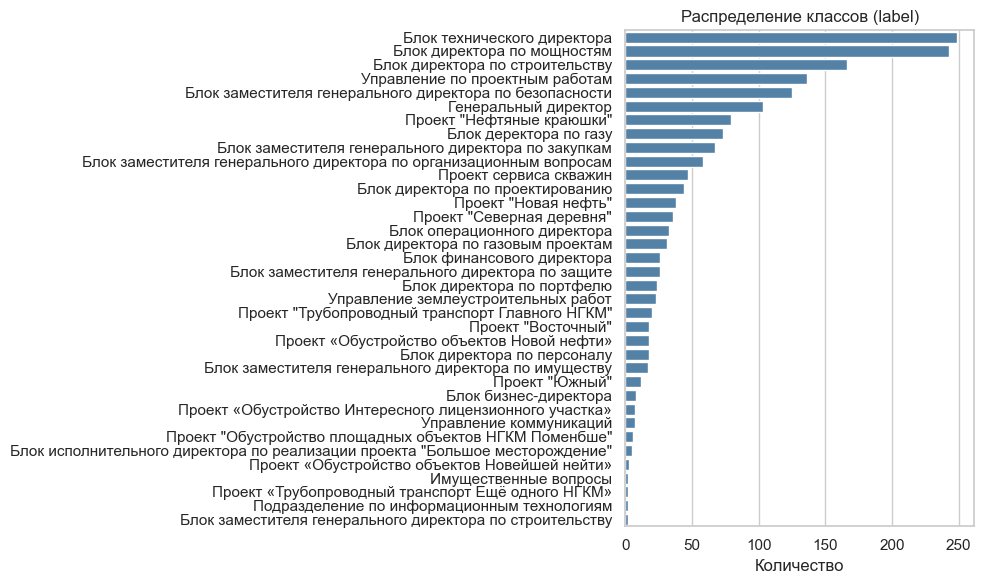

In [85]:
print("Классов:", label_counts.size)
print("min:", int(label_counts.min()), "max:", int(label_counts.max()))

# сколько классов имеют <= N примеров
for n in [5,10,20,50, 100, 150, 200, 240]:
    print(f"<= {n}: {(label_counts <= n).sum()} классов")

plt.figure(figsize=(10, 6))
sns.barplot(y=label_counts.index, x=label_counts.values, color="steelblue")
plt.title("Распределение классов (label)")
plt.xlabel("Количество")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [96]:
p = label_share.values

entropy = -(p * np.log(p + 1e-12)).sum()
norm_entropy = entropy / np.log(len(p))
effective_classes = np.exp(entropy)         
gini = 1 - np.sum(p**2)  

print("Классов:", label_counts.size)
print("Энтропия:", round(entropy, 4))
print("Норм. энтропия (0..1):", round(norm_entropy, 4))
print("Эффективное число классов exp(H):", round(effective_classes, 2))
print("Gini (1 - sum p^2):", round(gini, 4))

Классов: 36
Энтропия: 2.9704
Норм. энтропия (0..1): 0.8289
Эффективное число классов exp(H): 19.5
Gini (1 - sum p^2): 0.9281


In [100]:
label_counts = df["label"].value_counts()
share = label_counts / label_counts.sum()
cum = share.cumsum()

for q in [0.80, 0.90, 0.95, 0.99]:
    k = int((cum <= q).sum() + 1)
    print(f"{int(q*100)}% данных покрывают топ-{k} классов")

80% данных покрывают топ-13 классов
90% данных покрывают топ-19 классов
95% данных покрывают топ-24 классов
99% данных покрывают топ-30 классов


In [114]:
tail_n = 15
print("Суммарно примеров в этих классах:", int(label_counts.tail(tail_n).sum()))
print("Доля датасета:", round(label_counts.tail(tail_n).sum()/len(df), 4))

Суммарно примеров в этих классах: 127
Доля датасета: 0.0716


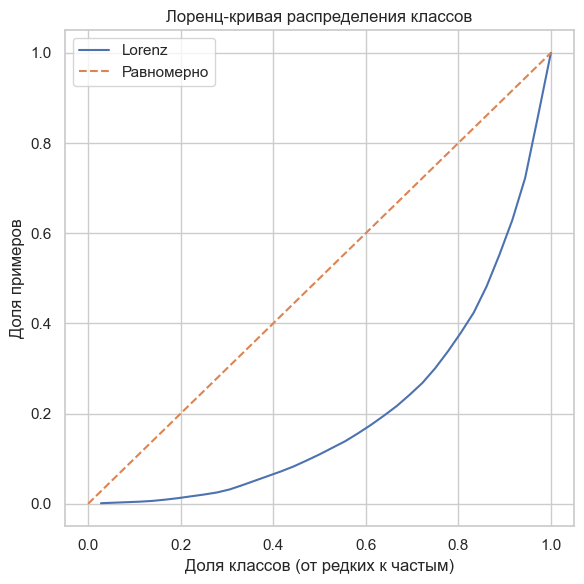

In [108]:
counts_sorted = label_counts.sort_values().values
cum_counts = np.cumsum(counts_sorted)
cum_share = cum_counts / cum_counts[-1]
x = np.arange(1, len(counts_sorted)+1) / len(counts_sorted)

plt.figure(figsize=(6,6))
plt.plot(x, cum_share, label="Lorenz")
plt.plot([0,1],[0,1], "--", label="Равномерно")
plt.title("Лоренц-кривая распределения классов")
plt.xlabel("Доля классов (от редких к частым)")
plt.ylabel("Доля примеров")
plt.legend()
plt.tight_layout()
plt.show()

В датасете **36 классов**, при этом распределение заметно неравномерное: размер класса варьируется от **2** до **249** примеров. Большая часть классов относится к “длинному хвосту”: **26 из 36** классов имеют **≤ 50** примеров, **30 из 36** — **≤ 100**, а **10 классов** имеют **≤ 10** примеров (из них **6 классов** — **≤ 5**). Это означает, что для значимой доли меток данных мало, и качество по этим классам будет нестабильным без дополнительных мер (веса классов, доразметка, объединение редких классов и т.п.).

По агрегированным метрикам дисбаланса распределение нельзя назвать “крайне перекошенным в один класс”, но оно существенно неравномерное. **Нормированная энтропия 0.8289** указывает на относительно высокое разнообразие классов, однако **эффективное число классов exp(H) ≈ 19.5** показывает, что по фактическому распределению данных задача ближе к классификации примерно на **~20 “равномерных” классов**, а оставшиеся классы вносят небольшой вклад и формируют хвост. Значение **Gini = 0.9281** также подтверждает, что масса не сосредоточена в одном-двух классах, но при этом не отменяет проблему редких классов.

Покрытие по кумулятивной доле дополнительно демонстрирует концентрацию данных в верхней части распределения: **80%** всех примеров дают **топ-13** классов, **90%** — **топ-19**, **95%** — **топ-24**, а чтобы покрыть **99%**, нужно уже **топ-30** классов. То есть последние ~6 классов дают суммарно около 1% данных.

Анализ “хвоста” (15 самых редких классов) показывает, что на них приходится **127 примеров**, то есть **~7.16%** датасета — это существенная доля, но размазанная по множеству малых классов. **Лоренц-кривая**, идущая “по дуге” ниже диагонали равномерности, визуально подтверждает неравномерность распределения: значимая часть примеров сосредоточена в относительно небольшом числе классов, а остальные классы представлены малым количеством наблюдений.

## Анализ текста

In [47]:
# базовая токенизация по пробелам
df["n_chars"] = df["text"].str.len()
df["n_words"] = df["text"].str.split().map(len)

df[["n_chars", "n_words"]].describe(percentiles=[.5, .75, .9, .95, .99]).T

,count,mean,std,min,50%,75%,90%,95%,99%,max
n_chars,1774.0,2923.601466,7091.163226,49.0,1277.5,1921.5,3590.6,6843.70,44951.03,69225.0
n_words,1774.0,315.519729,701.418785,8.0,149.0,230.0,424.7,846.75,4697.51,7455.0


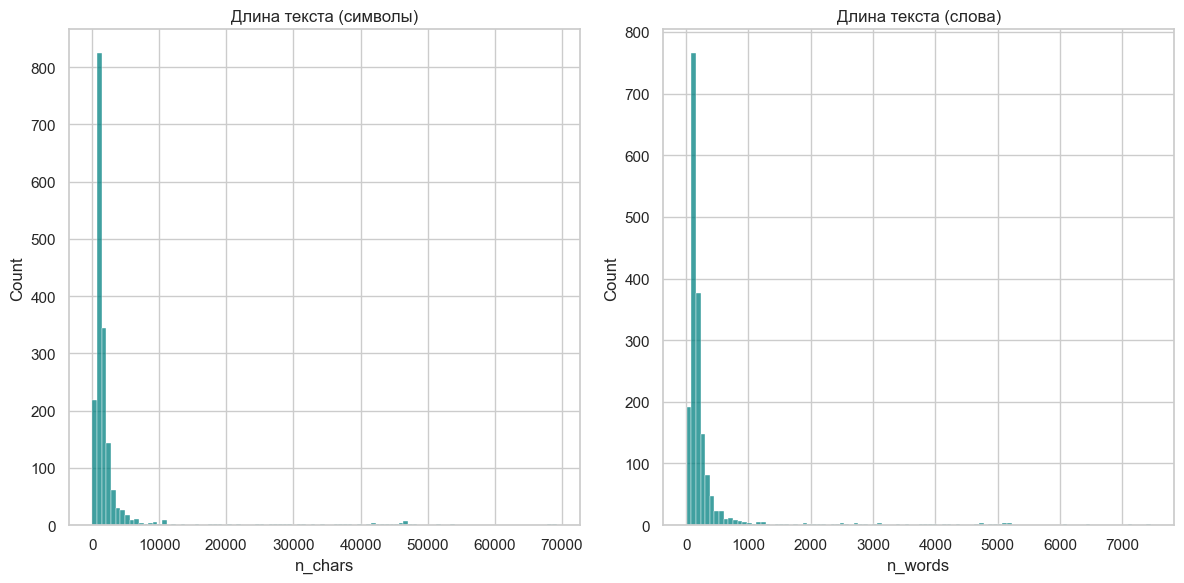

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

sns.histplot(df["n_chars"], bins=100, ax=axes[0], color="teal")
axes[0].set_title("Длина текста (символы)")

sns.histplot(df["n_words"], bins=100, ax=axes[1], color="teal")
axes[1].set_title("Длина текста (слова)")

plt.tight_layout()
plt.show()

Топ слов по всему датасету:

In [69]:
cnt = Counter()
for toks in df["tokens"]:
    cnt.update(toks)

cnt.most_common(30)

[('person', 52737),
 ('financial_data', 25475),
 ('organization', 25060),
 ('document_number', 22639),
 ('date_time', 17311),
 ('object', 16692),
 ('на', 12333),
 ('в', 10597),
 ('number', 9038),
 ('по', 8400),
 ('и', 7610),
 ('contact', 7259),
 ('no', 6911),
 ('от', 6577),
 ('с', 6358),
 ('id', 5965),
 ('product', 5242),
 ('приказы', 5048),
 ('наименование', 4939),
 ('location', 3974),
 ('type', 3414),
 ('отпускные', 2936),
 ('руб', 2683),
 ('1', 2671),
 ('к', 2640),
 ('услуг', 2593),
 ('о', 2464),
 ('для', 2044),
 ('тел', 1955),
 ('до', 1800)]